## Libaries

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
import mne

parent_dir = Path().resolve().parent.parent
sys.path.append(str(parent_dir))

from src.utilities.preprocessing import EEG_preprocessing, EMG_preprocessing       # noqa: E402
from src.utilities.load_and_visualize_data import load_datasets, visualize_EMG                    # noqa: E402

## Global variables

In [2]:
EMG_FREQ = 2000
EEG_FREQ = 125

EMG_LOWCUT = 20
EMG_HIGHCUT = 450
EEG_LOWCUT = 2
EEG_HIGHCUT = 32

EMG_NUM_CH = 3
EEG_NUM_CH = 16

NUM_EPOCHS = 30
TOTAL_EPOCHS = 90
TRIAL_PERIOD = 8
TRIM_PERIOD = 3

RMS_SAMPLING_WINDOW = 200
RMS_WINDOW_STEPSIZE = 50

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Pz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]
EMG_CH_NAMES = [
'Channel 1 : Flexor pollicis longus',
'Channel 2 : Flexor digitorum superficialis',
'Channel 3 : '
]

# EMG_CH_NAMES = [
# 'Channel 1 : Flexor digitorum superficialis',
# 'Channel 2 : Flexor pollicis longus', 
# 'Channel 3 : Extensor digitorum',
# 'Channel 4 : Extensor pollicis brevis/longus'
# ]

In [ ]:
# ----- Global style -----

plt.rcParams.update({
    # ---- Font ----
    "font.family": "serif",
    #"font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    #"mathtext.fontset": "stix",
    #"text.usetex": False,          # True for LaTeX rendering (optional)
    
    # ---- Font sizes (A4 layout, 10 pt doc) ----
    "font.size": 9,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    
    # ---- Line and color ----
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "axes.prop_cycle": plt.cycler(color=plt.cm.tab10.colors),

    # ---- Layout ----
    # Page size (247.000, 174.000) height, width
    # (5.5, 3.5) half-page 
    #"figure.figsize": (5.5, 3.5),  
    "figure.dpi": 400,
    "savefig.transparent": True,
    "savefig.bbox": "tight"
})

## Load multiple csv files

In [12]:
#------------------------#
# Select what to inspect #
#------------------------#
base_dir = Path().resolve() / 'data'

load_ins = load_datasets(base_dir = base_dir)

EMG_index_files = load_ins.find_flex_files(
    subjects = 'subject_1',
    modality = 'EMG',
    fingers = 'index',
    prefix = 'flex'
)

EMG_thumb_files = load_ins.find_flex_files(
    subjects = 'subject_1',
    modality = 'EMG',
    fingers = 'thumb',
    prefix = 'flex'
)

In [13]:
EMG_ins = EMG_preprocessing(fs = EMG_FREQ,
                            bandpass_lowcut = EMG_LOWCUT,
                            bandpass_highcut = EMG_HIGHCUT,
                            num_epochs = NUM_EPOCHS,
                            trial_period = TRIAL_PERIOD,
                            trim_period = TRIM_PERIOD)

EMG_index, EMG_index_epoch, EMG_index_epoch_mean = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_index_files[1:4],
    preprocessing_func = EMG_ins.preprocessing_routine
)


RMS_index, RMS_index_epoch, RMS_index_epoch_mean = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_index_files[1:4],
    preprocessing_func = EMG_ins.preprocessing_routine_rms,
    sample_window = RMS_SAMPLING_WINDOW,
    window_stepsize = RMS_WINDOW_STEPSIZE
)

EMG_thumb, EMG_thumb_epoch, EMG_thumb_epoch_mean = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_thumb_files,
    preprocessing_func = EMG_ins.preprocessing_routine
)


RMS_thumb, RMS_thumb_epoch, RMS_thumb_epoch_mean = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_thumb_files,
    preprocessing_func = EMG_ins.preprocessing_routine_rms,
    sample_window = RMS_SAMPLING_WINDOW,
    window_stepsize = RMS_WINDOW_STEPSIZE
)


--------------------------
Process to obtain EMG data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000


--------------------------
Process to obtain EMG data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000


--------------------------
Process to obtain EMG data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Total Time 240 s
Real fs: 2000.0 Hz
Target len: 480000
EMG original len: 480000

Reshaped data shape: (1440000, 3)
Samples per epoch: 16000
Epoched data shape: (90, 16000, 3)
Mean epoch data shape: (16000, 3)

--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 960

## EMG Section

### Normalization functions

In [ ]:
def MVC_EMG(json_filepath, EMG_raw):
    with open(fr'data\{json_filepath}') as f:
        calib_read = json.load(f)

    calib_dist = {}
    EMG_calib = []

    
    for k, (ch, value) in enumerate(calib_read.items()):
        ref = value['baseline_noise']
        mvc = value['MVC']
        print(f'baseline: {ref} \n mvc: {mvc}')
        
    
        calib_dist[ch] = {
            'ref' : ref,
            'mvc' : mvc
        }

        #print(f"{ch}: baseline={ref}, mvc={mvc}")
        
        if isinstance(EMG_raw, pd.DataFrame):
            normalized = ((EMG_raw.values[:, k] - ref) / (mvc - ref)) * 100
            EMG_calib.append(normalized)
            
        else:
            normalized = (EMG_raw[:, k] - ref) / (mvc - ref) * 100
            EMG_calib.append(normalized)
        
    EMG_calib = np.array(EMG_calib).T

    return EMG_calib

## Plot EMG

In [5]:
def mm_to_inches(mm):
    return mm / 25.4

def plot_emg_mean_epoch_single_channels(emg_epoch_mean, rms_epoch_mean, ch1 = 0, ch2 = 1):

    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(70)),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    #print('Channel Name :', EMG_CH_NAMES[emg_ch], 'and', EMG_CH_NAMES[rms_ch])

    emg1 = np.array(emg_epoch_mean[:, ch1])
    rms1 = np.array(rms_epoch_mean[:, ch1])

    emg2 = np.array(emg_epoch_mean[:, ch2])
    rms2 = np.array(rms_epoch_mean[:, ch2])

    time = np.arange(emg1.shape[0]) / EMG_FREQ
    RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
    win_time = (np.arange(rms1.shape[0]) * (RMS_window_size/4) + RMS_window_size/4) / EMG_FREQ

    axs[0].plot(time, emg1, color='royalblue', linewidth=1.0, label = 'Index finger')
    axs[0].plot(win_time, rms1, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    axs[0].set_xlim([0, 9])
    axs[0].set_ylim([-2, 2])
    axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EMG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc = 'lower left')

    axs[0].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[0].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

    axs[1].plot(time, emg2, color='royalblue', linewidth=1.0, label='Thumb')
    axs[1].plot(win_time, rms2, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    axs[1].set_xlim([0, 9])
    axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc = 'lower left')

    axs[1].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[1].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    
    #plt.savefig(fr'images\Nicklas_wrist_EMG\Mean_EEG_epoch_{key1}_ch{ch1}_and_{key2}_ch{ch2}_report.pdf')

vis_EMG_ins = visualize_EMG(fs = EMG_FREQ,
                            rms_sampling_window = RMS_SAMPLING_WINDOW,
                            rms_windows_stepsize = RMS_WINDOW_STEPSIZE,
                            which_finger = 'unsued',
                            num_epochs = NUM_EPOCHS,
                            total_epochs = TOTAL_EPOCHS,
                            trial_period = TRIAL_PERIOD)

In [ ]:
plot_emg_mean_epoch_single_channels(EMG_index_epoch_mean, RMS_index_epoch_mean, ch1 = 0, ch2 = 1)

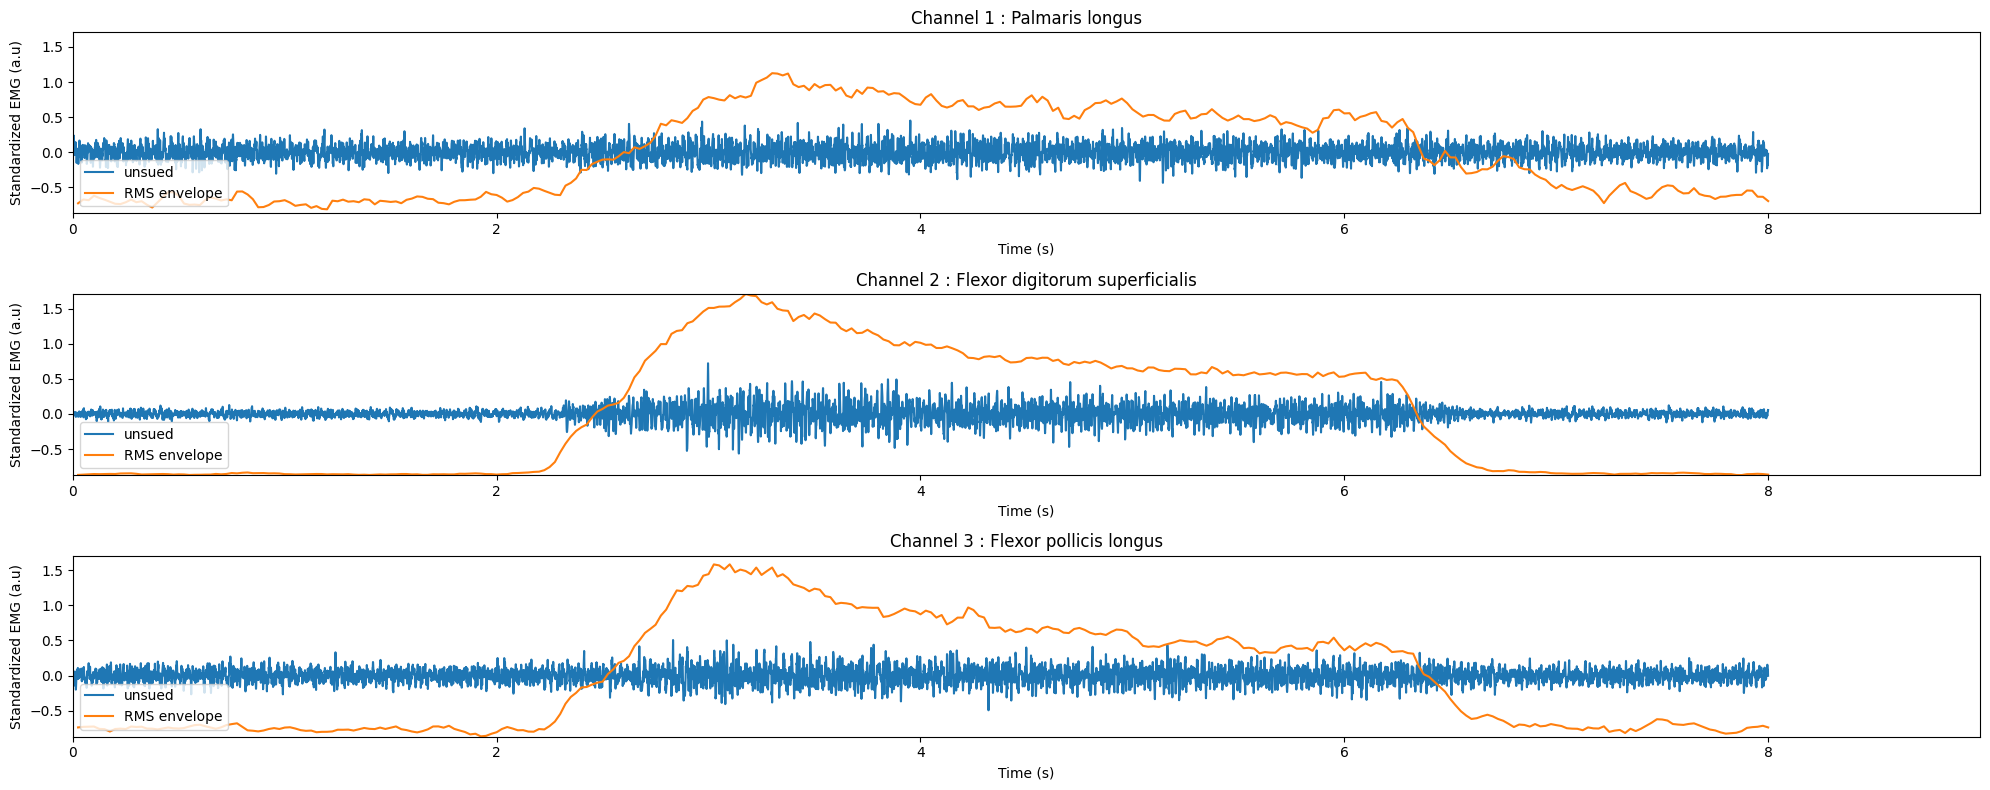

In [32]:
vis_EMG_ins.plot_rms_across_channels(EMG_index_epoch_mean, RMS_index_epoch_mean, None, 0)

## Box plot

In [29]:
def box_plot_across_channels(epoch_data, range_of_interst = 0):
    
    fingers = list(epoch_data.keys())
    n_ch = epoch_data[fingers[0]].shape[2]

    group_spacing = 1.2      # spacing between channels inside a finger-group
    finger_spacing = n_ch + 1 # spacing between finger groups

    if isinstance(range_of_interst, int):
        range_of_interst = np.arange(0, epoch_data[fingers[0]].shape[1])
        print('enter')

    # colors = [
    #     'royalblue',   # thumb
    #     'darkorange',  # index
    #     'forestgreen', # middle
    #     'firebrick',   # ring
    #     'purple',      # little
    #     'saddlebrown'  # palm
    # ]
    channel_colors = [
        'royalblue',   # ch1
        'darkorange',  # ch2
        'forestgreen', # ch3
    ]
    flierprops=dict(
        marker='*',
        markersize=0.5,
        markerfacecolor='black',
        markeredgecolor='black',
        alpha=0.6
    )

    positions = []
    labels = []
    all_box_data = []

    #plt.figure(figsize=(mm_to_inches(162/2), mm_to_inches(60)))
    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(60)),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )

    for f_idx, finger in enumerate(fingers):

        # data shape = (epochs, samples, channels)
        n_epo, n_sam, n_ch = epoch_data[finger][:, range_of_interst, :].shape

        # flatten epochs + samples
        EMG_flat = epoch_data[finger][:, range_of_interst, :].reshape(n_epo*n_sam, n_ch)

        for ch in range(n_ch):            
            all_box_data.append(EMG_flat[:, ch])

            # compute x-position for this box
            pos = f_idx * finger_spacing + ch * group_spacing
            positions.append(pos)

            labels.append(f"{finger.capitalize()}  ch{ch+1}")

   # ---- Draw boxplot
    bp = axs[0].boxplot(
        all_box_data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        flierprops = flierprops,
        medianprops=dict(color='black', linewidth=1.6),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )

    # ---- Apply consistent channel colors
    for i, box in enumerate(bp['boxes']):
        ch = i % n_ch
        box.set_facecolor(channel_colors[ch])
        box.set_alpha(0.85)

        # ---- Aesthetics
    axs[0].set_xticks(positions, labels, rotation=15, ha='right')
    axs[0].set_ylabel("RMS EMG amplitude")
    #axs[0].set_ylim([-2, 2])

    axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    
    #plt.savefig(r'images\Nicklas_wrist_EMG\boxplot_RMS_across_ch_and_class.pdf')

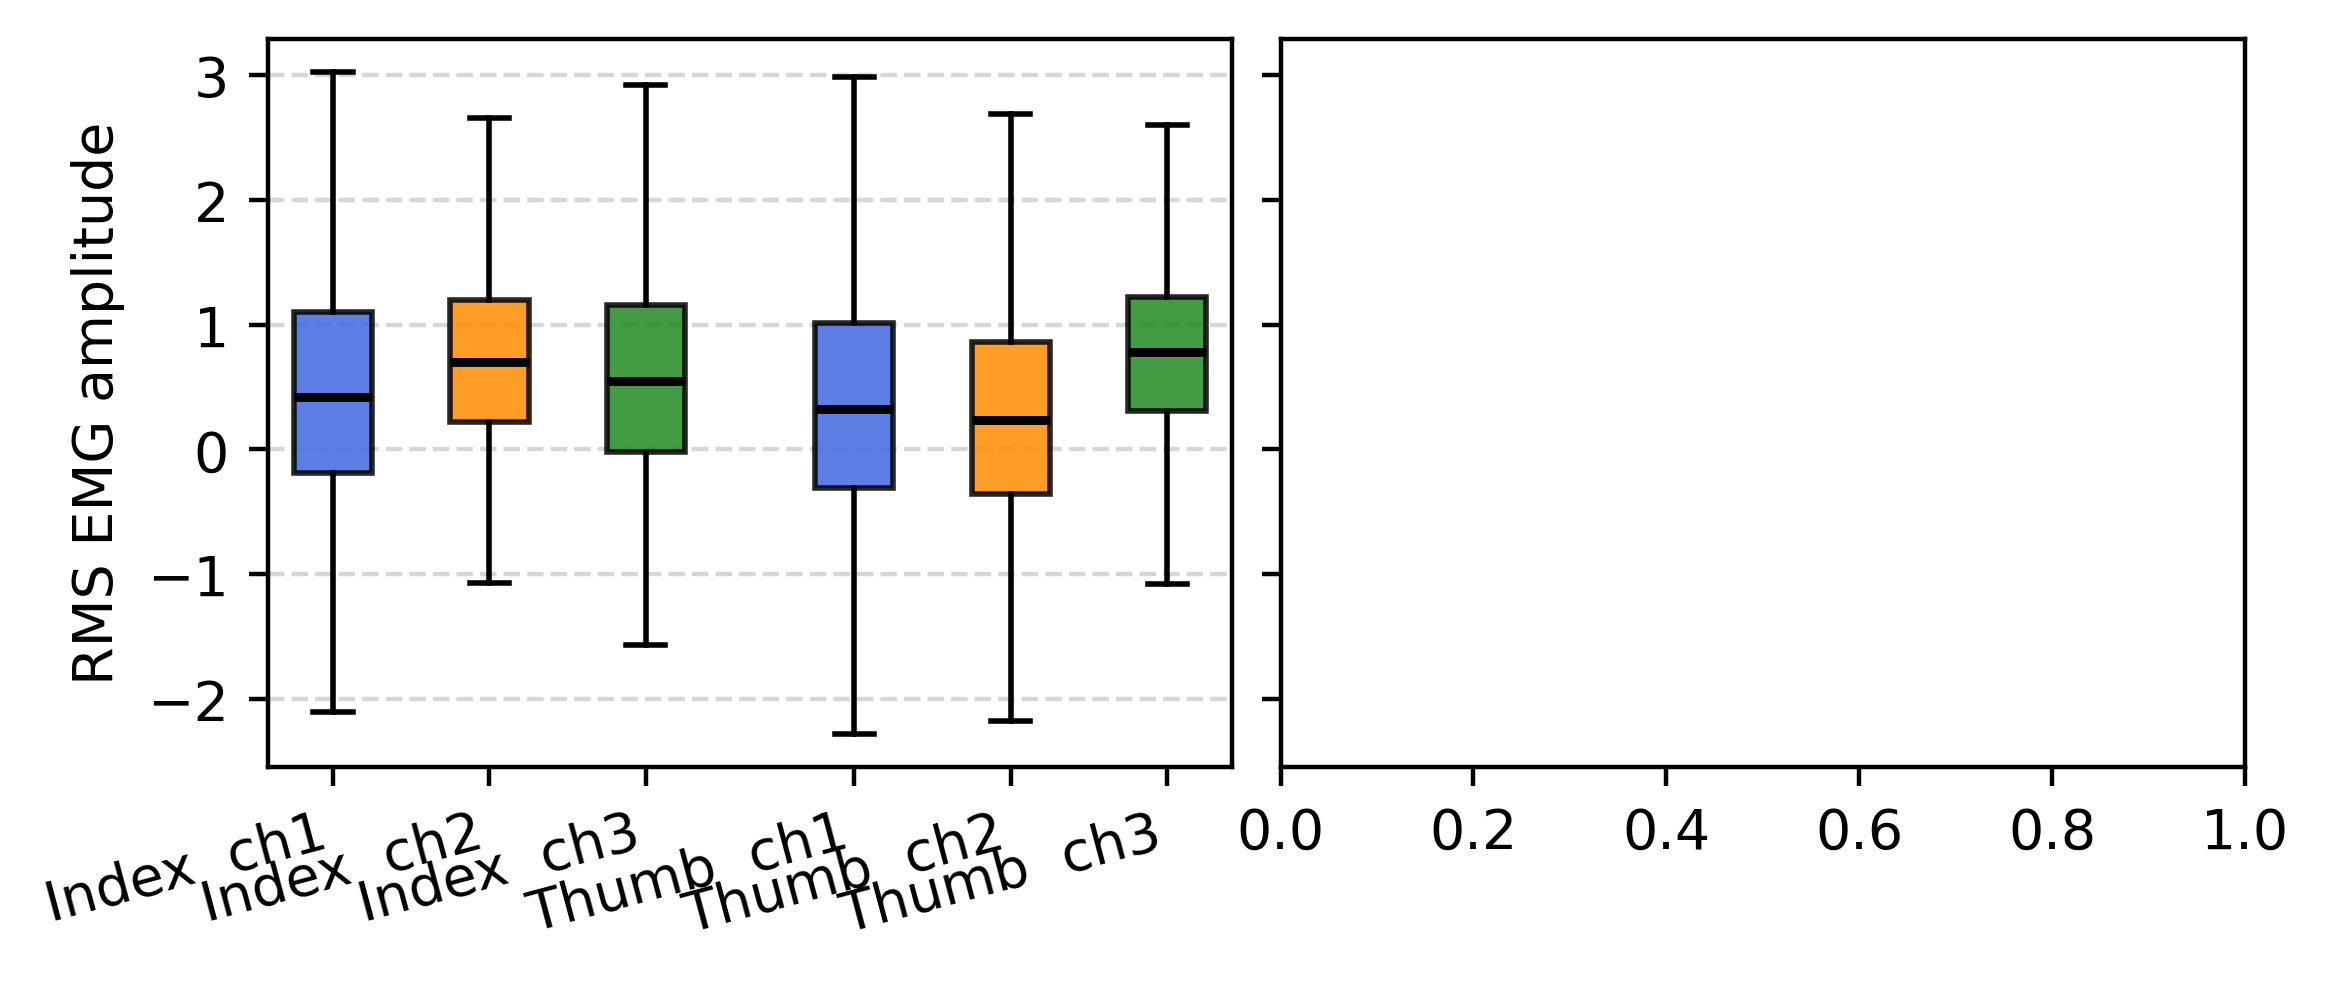

In [30]:
RMS_dict = {}

RMS_dict['index'] = RMS_index_epoch
RMS_dict['thumb'] = RMS_thumb_epoch

ONE_SEC_RANGE = RMS_index_epoch.shape[1] // TRIAL_PERIOD
CON_RANGE = np.arange(2*ONE_SEC_RANGE, 6*ONE_SEC_RANGE)

box_plot_across_channels(RMS_dict, CON_RANGE)


## EEG Section

## ERD/ERS/MRCP

In [58]:
EEG_ins = EEG_preprocessing(125)

EEG_index_files = load_ins.find_flex_files(
        subjects = 'subject_1',
        modality = 'EEG',
        fingers = 'index',
        prefix = 'flex'
    )

EEG_thumb_files = load_ins.find_flex_files(
        subjects = 'subject_1',
        modality = 'EEG',
        fingers = 'thumb',
        prefix = 'flex'
    )

EEG_index, EEG_index_epoch, EEG_index_epoch_mean = load_ins.load_datasets_EEG(
        path_to_data_files = EEG_index_files[1:4],
        preprocessing_func = EEG_ins.preprocessing_routine,
        bandpass_lowcut = EEG_LOWCUT,
        bandpass_highcut = EEG_HIGHCUT,
        extract_event = 'contract'
    )

EEG_thumb, EEG_thumb_epoch, EEG_thumb_epoch_mean = load_ins.load_datasets_EEG(
        path_to_data_files = EEG_thumb_files,
        preprocessing_func = EEG_ins.preprocessing_routine,
        bandpass_lowcut = EEG_LOWCUT,
        bandpass_highcut = EEG_HIGHCUT,
        extract_event = 'contract'
    )

------------------
Process for EEG data
------------------

Reshaped data shape: (90000, 16)
Samples per epoch: 1000
Epoched data shape: (90, 1000, 16)
Mean epoch data shape: (1000, 16)
------------------
Process for EEG data
------------------

Reshaped data shape: (90000, 16)
Samples per epoch: 1000
Epoched data shape: (90, 1000, 16)
Mean epoch data shape: (1000, 16)


## ERSP computational functions

In [35]:
def compute_mrcp(epochs_mean):
    """
    epochs: array (n_samples, n_channels)
    baseline_samples: baseline region before movement

    Returns: mrcp (channels x samples)
    """
    r0 = 0
    k = 250

    baseline = epochs_mean[r0:r0+k, :]
    R = baseline.mean(axis=0, keepdims=True)

    epochs_baselined = epochs_mean - R
    
    #mrcp = epochs_baselined.mean(axis=0)

    return epochs_baselined

def compute_ERD_ERS_pfurtscheller(epoch, fs = 125):
    """
    resampled_data: (np.Array) 
        shape (n_samples, n_channels)
    """
    eps = 1e-12
    
    r0 = fs * 0     # samples for x seconds
    k = fs * 2      # samples for x seconds

    power = epoch**2
    
    # 3) Act(j): average power across trials
    Act = np.mean(power, axis=0)
    print(f'Act.shape: {Act.shape}')

    # 4) Baseline R
    baseline = Act[r0:r0+k, :]
    R = np.mean(baseline, axis = 0)

    print(f'R value: {R}')
    
    # 5) ERD/ERS
    rts = ((Act - R) / (R + eps)) * 100

    return rts

def compute_erd_ers_pywt(epoch_mean, freq_min, freq_max, freq_bins = 75):
    wt_obj = "morl"
    wt_dt = 1/EEG_FREQ
    wt_freqs_interst = np.linspace(freq_min, freq_max, freq_bins)
    wt_scales = pywt.frequency2scale(wt_obj, wt_freqs_interst) / wt_dt

    r0 = 0
    k = 250
    eps = 1e-12

    n_samples, n_channels = epoch_mean.shape
    erd_ers = np.zeros_like(epoch_mean, dtype=np.float32)

    for sch in range(n_channels):
            wt_coef, wt_freq = pywt.cwt(
                data =  epoch_mean[:, sch],
                scales = wt_scales,
                wavelet = wt_obj,
                method = 'conv',
                sampling_period=wt_dt,
                precision = 12
            )
            # Power (scales × samples)
            power = np.abs(wt_coef)**2

            # Collapse across scales (band average)
            band_power = power.mean(axis=0) # shape = (samples,)

            # Baseline
            baseline = band_power[r0:r0+k].mean()
            
            # ERD/ERS
            erd_ers[:, sch] = (band_power - baseline) / (baseline + eps) * 100
    
    return erd_ers, wt_freq

def plot_wavelet_spectrogram(epoch_mean, freq_bands={'mu': (8, 13), 'beta': (13, 30)}, freq_bins = 75):
    
    for freq_interst in freq_bands.keys():
        erd_ers, wt_freq = compute_erd_ers_pywt(epoch_mean = epoch_mean,
                                       freq_min = freq_bands[freq_interst][0], 
                                       freq_max = freq_bands[freq_interst][1],
                                       freq_bins = freq_bins)
    
        plt.figure(figsize=(10, 5))
        extent = [0, len(erd_ers)/EEG_FREQ, freq_bands['mu'][0], freq_bands['beta'][1]]
        
        for sch in range(EEG_NUM_CH):
            X = erd_ers[:, sch]

            plt.imshow(
                [X, wt_freq],
                aspect='auto',
                origin='lower',
                extent=extent,
                cmap='turbo'
            )

    plt.colorbar(label="Power change (%)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Baseline-corrected Wavelet Spectrogram\nChannel {EEG_CH_NAMES[sch]}")
    plt.axhline(8, color='white', linestyle='--', alpha=0.6)
    plt.axhline(13, color='white', linestyle='--', alpha=0.6)
    plt.axhline(30, color='white', linestyle='--', alpha=0.6)
    plt.show()

## Plot functions

In [64]:
def plot_mrcp_across_channels_separate(epoch_mean):
    """
    Plots the MRCP for each channel.

    Args:
        mrcp (np.ndarray): 2D array of shape (n_samples, n_channels)
    """
    fig, axes = plt.subplots(EEG_NUM_CH, len(epoch_mean), figsize = (20, 40))
    
    for i, finger in enumerate(epoch_mean.keys()):
        time = np.arange(epoch_mean[finger].shape[0]) / EEG_FREQ
        mrcp = compute_mrcp(epoch_mean[finger])

        for ch in range(EEG_NUM_CH):
            axes[ch, i].plot(time, mrcp[:, ch])
            axes[ch, i].set_title(f'MRCP - For {finger} at channel {EEG_CH_NAMES[ch]}')
            
            axes[ch, i].set_xlabel('Time')
            axes[ch, i].set_ylabel('Amplitude [a.u]')

            axes[ch, i].axhline(0, color='black', linestyle = '-', linewidth=1)  # baseline line
            axes[ch, i].axvline(2, color='green', linestyle='-.', label="Contract")
            axes[ch, i].axvline(7, color='red', linestyle='--', label="Release")
            axes[ch, i].legend(loc='upper right')
        
    fig.tight_layout()

def plot_mrcp_across_channels_together(epoch_mean, single_plot_flag = 0):
    """
    Plots the MRCP for each channel.

    Args:
        mrcp (np.ndarray): 2D array of shape (n_samples, n_channels)
    """
    fig, axes = plt.subplots(EEG_NUM_CH, 1, figsize = (10, 40))
    single_plot_flag = 0

    for finger in epoch_mean.keys():
        time = np.arange(epoch_mean[finger].shape[0]) / EEG_FREQ
        mrcp = compute_mrcp(epoch_mean[finger])

        for ch in range(EEG_NUM_CH):
            axes[ch].plot(time, mrcp[:, ch], label = finger)
            
            if single_plot_flag == 1:
                axes[ch].set_title(f'MRCP - For {finger} at channel {EEG_CH_NAMES[ch]}')
                
                axes[ch].set_xlabel('Time')
                axes[ch].set_ylabel('Amplitude [a.u]')
                
                axes[ch].axhline(0, color='black', linestyle = '-', linewidth=1)  # baseline line
                axes[ch].axvline(2, color='green', linestyle='-.', label="Contract")
                axes[ch].axvline(7, color='red', linestyle='--', label="Release")
                axes[ch].legend(loc='lower left')
        
        single_plot_flag = 1
        
    fig.tight_layout()

def plot_mean_epoch_across_channels(data):
    n_channels = 16

    fig, axes = plt.subplots(n_channels, len(data), figsize = (20, 40))
    for i, finger in enumerate(data.keys()):
        time = np.arange(data[finger].shape[0]) / EEG_FREQ

        for ch in range(n_channels):

            if len(data.keys()) == 1:
                ax = axes[ch]
            else:
                ax = axes[ch, i]

            ax.plot(time, data[finger][:,ch])
            ax.set_title(f'For {finger} at channel {EEG_CH_NAMES[ch]}')
            
            ax.set_xlabel('Time')
            ax.set_ylabel('Amplitude [a.u]')

            ax.axhline(0, color='black')
            ax.axvline(2, color='green', linestyle='-.', label="Contract")
            ax.axvline(7, color='red', linestyle='--', label="Release")
            ax.legend(loc='upper right')

    fig.tight_layout()

def plot_mean_epoch_single_channels(data, ch1 = 0, ch2 = 1, finger1 = None, finger2 = None):

    
    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(60)),
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    print('Channel Name :', EEG_CH_NAMES[ch1], 'and', EEG_CH_NAMES[ch2])
    
    time = np.arange(data[finger1].shape[0]) / EEG_FREQ

    axs[0].plot(time, data[finger1][:,ch1], color='royalblue', linewidth=1.0, label='Index finger')
    axs[0].set_xlim([0, 8])
    axs[0].set_ylim([-0.6, 0.6])
    axs[0].set_xticks(np.arange(0.0, 8.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EEG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(time, data[finger2][:,ch2], color='royalblue', linewidth=1.0, label='Index finger')
    axs[1].set_xlim([0, 8])
    #axs[1].set_ylim([-0.6, 0.6])
    axs[1].set_xticks(np.arange(0.0, 8.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    #axs[1].set_ylabel('Standardized EEG (a.u)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    
    plt.savefig(fr'images\Nicklas_wrist_EMG\Mean_EEG_epoch_{finger1}_{EEG_CH_NAMES[ch1]}_and_{finger2}_{EEG_CH_NAMES[ch2]}_report.pdf')

def plot_EEG_sequence_across_channels(data, st = 0, end = 9, fs = 125):
    xmin = st * fs
    xmax = end * fs
    n_samples, n_channels = data[xmin:xmax, :].shape
    col_size = 2 * n_channels
    row_size = 0.009 * n_samples 
    time = np.arange(n_samples) / fs

    fig, ax = plt.subplots(nrows = n_channels, ncols = 1, figsize = (row_size, col_size))
    
    for i in range(n_channels):
        ax[i].plot(time, data[xmin:xmax, i], label = f"EEG ch {EEG_CH_NAMES[i]}")
        ax[i].set_xticks(np.arange(0, 9, 1))

    plt.show()

In [60]:
EEG_dict = {}
EEG_dict['index'] = EEG_index_epoch_mean
EEG_dict['thumb'] = EEG_thumb_epoch_mean

Channel Name : C3 and C3


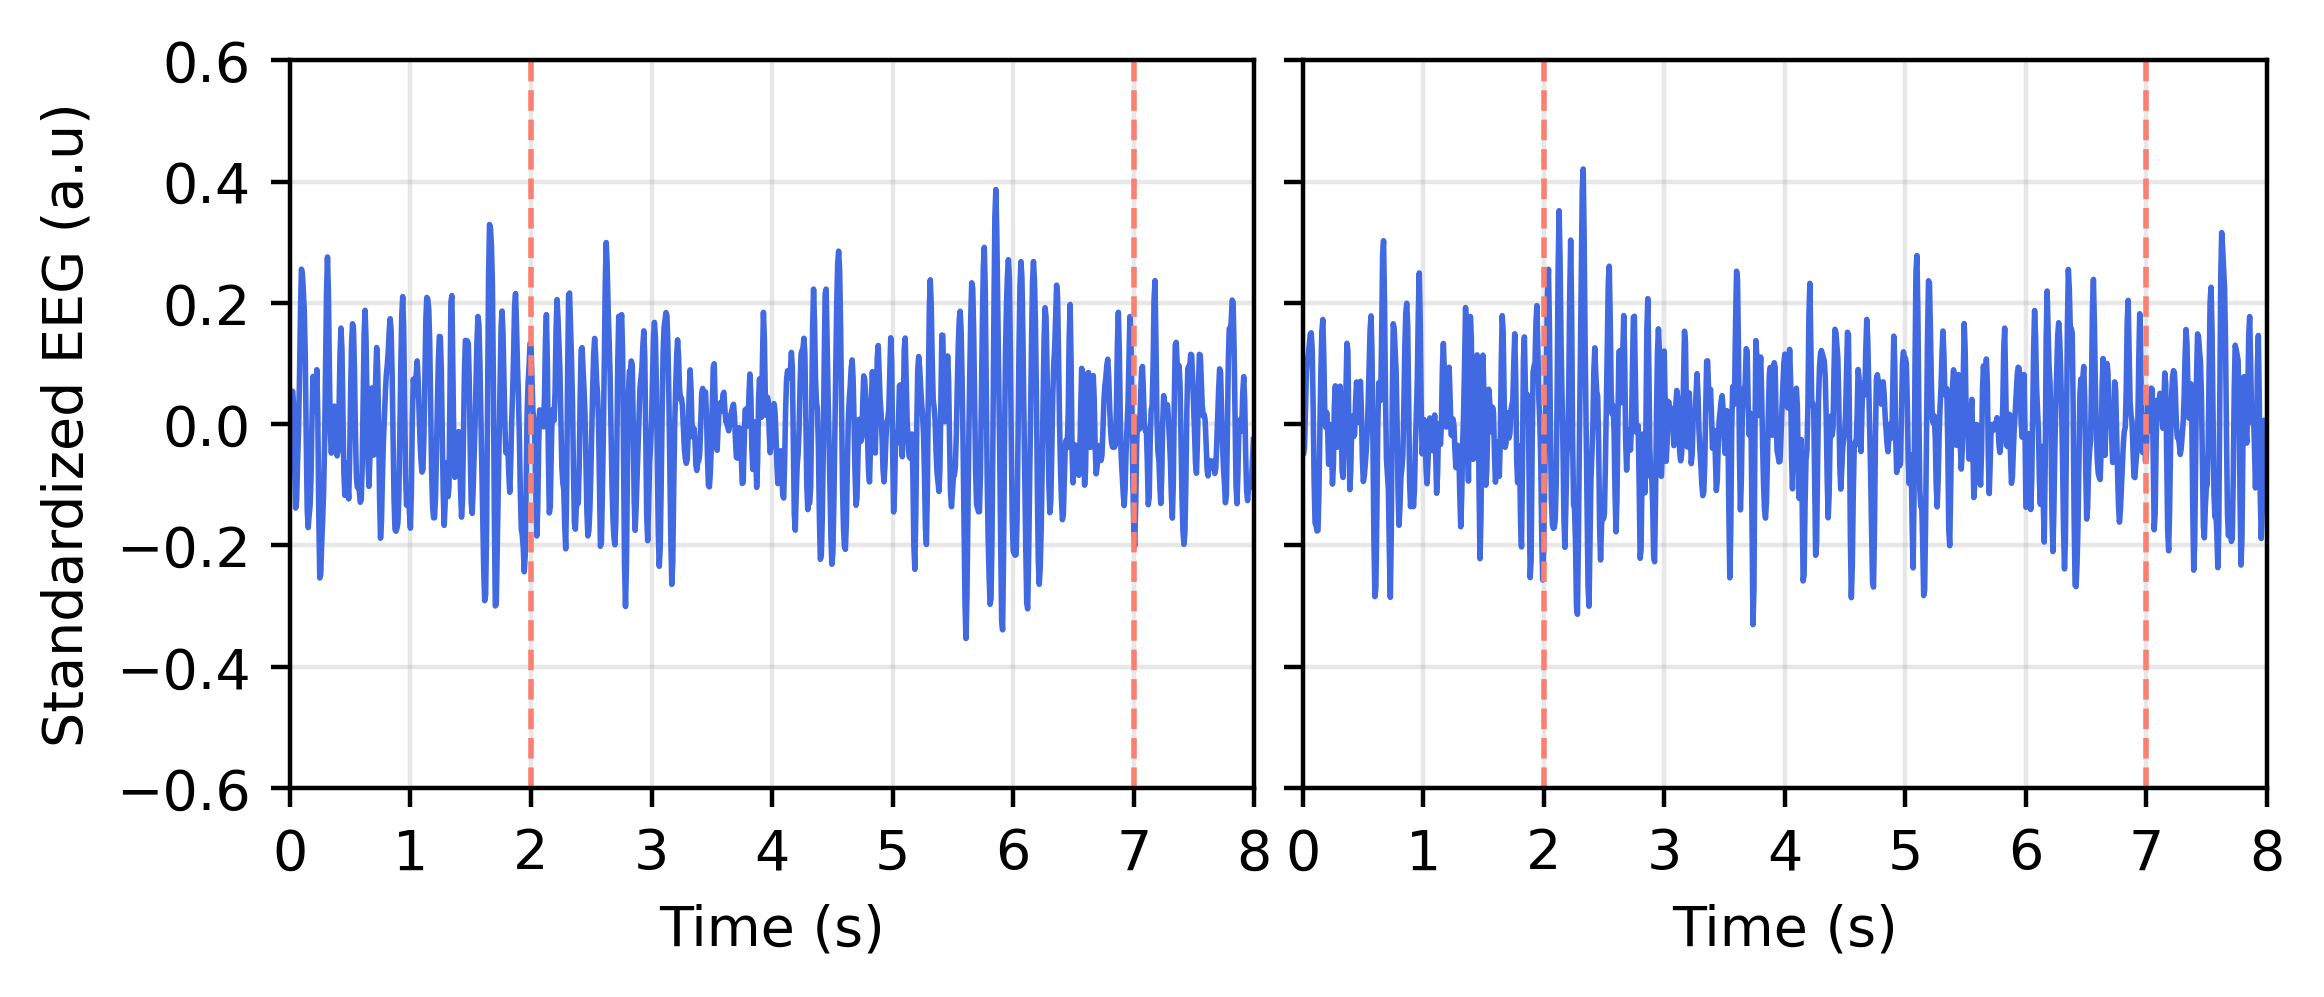

In [65]:
plot_mean_epoch_single_channels(EEG_dict, ch1 = 2, ch2 = 2, finger1 = 'index', finger2='thumb')

## Visualize topoplot with MNE

### 1. Load your custom electrode positions (.sfp)

In [ ]:
channel_location_dir = str(parent_dir) + "\\utilities\\electrode_positions_16channel_modifed.sfp"

montage = mne.channels.read_custom_montage(channel_location_dir)
montage

### 2. Create MNE Info object

In [ ]:
ch_names = montage.ch_names
n_channels = len(ch_names)

info = mne.create_info(
    ch_names = ch_names,
    sfreq = EEG_FREQ,
    ch_types = 'eeg'
)

# Attach your custom montage
info.set_montage(montage)

### EKSTRA: ERD topo plot

In [ ]:
ERD_T = MRCP.T # shape -> (channels, samples)

evoked = mne.EvokedArray(ERD_T, info, tmin=0)

In [ ]:
# Keep to remain the scale
vmax = np.percentile(np.abs(ERD_T), 100)
vlim = (-vmax, vmax)

In [ ]:
times = [2.8, 5.0, 7.8]   # seconds relative to your epoch start

fig = evoked.plot_topomap(
    times=times,
    ch_type='eeg',
    cmap='RdBu_r',
    size=1,
    time_unit='s',
    scalings=1,
    vlim=vlim,
    show=True
)


fig.savefig("mrcp_topomap_index.pdf", dpi=400, bbox_inches="tight")

### 3. Convert your numpy epochs into MNE Epochs

In [ ]:
# Reshape, because MNE needs the dimensions of: (n_epochs, n_channels, n_samples)
select_data_epoch_index = EEG_epoch['index'].transpose(0, 2, 1).copy() * 1e-6   # convert µV → V
select_data_epoch_thumb = EEG_epoch['thumb'].transpose(0, 2, 1).copy() * 1e-6   # convert µV → V 

epochs_mne_index = mne.EpochsArray(select_data_epoch_index, info=info, verbose=False)
epochs_mne_thumb = mne.EpochsArray(select_data_epoch_thumb, info=info, verbose=False)

# Compute evoked response (average across epochs)
evoked_index = epochs_mne_index.average()
evoked_thumb = epochs_mne_thumb.average()

In [ ]:
print(f"select_data_epoch_index shape: {select_data_epoch_index.data.shape}\n"
      f"evoked_index shape: {evoked_index.data.shape}")

### 4. Create a beautiful topoplot

In [ ]:
# Time (in seconds) you want to visualize
time_to_plot = 8

fig = evoked_index.plot_topomap(
    times=[time_to_plot],
    ch_type='eeg',
    cmap='RdBu_r',
    size=3,
    show=False
)

plt.show()

### 5. Multiple topoplots across time

In [ ]:
times = [1, 2, 7]  # seconds

fig = evoked_index.plot_topomap(
    times=times,
    ch_type='eeg',
    cmap='RdBu_r',
    size=3,
    show=False
)

plt.show()

### 7. Compare two classes: thumb vs index

In [ ]:
# Difference map
evoked_diff = mne.combine_evoked([evoked_index, evoked_thumb], weights=[1, -1])

evoked_diff.plot_topomap(times=[0.3, 0.5, 0.7], cmap='RdBu_r', size=3)


## Step-by-step solution: windowed topomaps

## 1. Extract window-averaged topographies

In [ ]:
# Define time window 
time_windows = [
    (0.6, 1.0),
    (2.6, 3.0),
    (7.6, 8.0)
]

topomaps = []
times_for_plot = []

for tmin, tmax in time_windows:
    # Crop evoked to window
    evoked_win = evoked_index.copy().crop(tmin=tmin, tmax=tmax)

    # Average across time → (n_channels,)
    topo = evoked_win.data.mean(axis=1)
    topomaps.append(topo)

    # For labeling only
    times_for_plot.append((tmin + tmax) / 2)

## 3. Plot them as a row of scalp maps

In [ ]:
fig, axes = plt.subplots(1, len(topomaps), figsize=(12, 4))
vlim = max(abs(np.concatenate(topomaps)))

for i, topo in enumerate(topomaps):
    im, _ = mne.viz.plot_topomap(
        topo,
        evoked_index.info,
        axes=axes[i],
        cmap='RdBu_r',
        vlim=(-vlim, vlim),
        show=False
    )
    axes[i].set_title(f"{time_windows[i][0]}–{time_windows[i][1]} s")

# ---- Add shared colorbar ----
cbar = fig.colorbar(im, ax=axes, shrink=0.7)
cbar.set_label("Amplitude (µV)")

#plt.tight_layout()
plt.show()
